# 01 · Baseline — a 20M LLM on TinyStories (50M tokens)

**ERA V5 · Session 13 (Reversibility)**, part 1 of 3.

Train a ~20M-parameter GPT for a 50M-token budget with a **fixed batch size that runs**. This is the *standard residual* baseline (the Euler update `p_{l+1} = p_l + f(p_l)`); autograd stores every layer's activations.

| setting | value |
|---|---|
| params | ~20.1M |
| layers × width | 9 × 256 |
| heads | 8 |
| context | 512 |
| vocab | 50257 (GPT-2 BPE) |
| data | TinyStories |
| optimizer | AdamW, cosine LR, warmup |
| device | Apple M3 Max (MPS) |

Hardware: Apple **M3 Max**, 68.7 GB unified memory, `torch` MPS backend (no CUDA). All modules live in [`revllm/`](../revllm).

In [1]:
import os, sys, json
# make the revllm package importable whether run from repo root or notebooks/
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "revllm")):
        REPO = p
        if p not in sys.path:
            sys.path.insert(0, p)
        break
assert REPO, "could not locate the revllm package"
RESULTS = os.path.join(REPO, "results")
import torch
from revllm.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/DistributedTraining_2 | device: mps | torch: 2.13.0


## The model
A compact GPT. The transformer block is exposed as a pure function `f_theta(p)` (attention then FFN, no residual add of its own) so the *same* block definition drives both the standard and reversible stacks.

In [2]:
from revllm.model import GPT, GPTConfig
cfg = GPTConfig(n_layer=9, n_embd=256, n_head=8, block_size=512,
                mode='standard', integrator='euler')
model = GPT(cfg)
print(f'parameters: {model.num_params()/1e6:.2f}M  (non-embedding {model.num_params(True)/1e6:.2f}M)')

parameters: 20.11M  (non-embedding 19.97M)


## Data
TinyStories, tokenized with GPT-2 BPE into `data/{train,val}.bin` (uint16). `prepare()` is idempotent — it reuses the cache.

In [3]:
from revllm.data import prepare, TokenData
train_bin, val_bin = prepare()
td = TokenData(train_bin)
print(f'train tokens: {len(td):,}')
import tiktoken; enc = tiktoken.get_encoding('gpt2')
print(repr(enc.decode(td.data[:60].tolist())))

[data] cached: /Users/sokorada/Documents/ERA_V5/DistributedTraining_2/data/train.bin, /Users/sokorada/Documents/ERA_V5/DistributedTraining_2/data/val.bin
train tokens: 60,000,057
'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said,'


## A short live demo (≈300K tokens)
Just to show the loop runs and the loss falls. The **reported** numbers come from the full 50M-token run below.

In [4]:
from revllm.engine import train_run
demo = train_run(cfg, name='demo_baseline', batch_size=32, token_budget=300_000,
                 train_bin=train_bin, val_bin=val_bin, device=DEVICE, log_every=5)
print(demo.summary())

[demo_baseline] step     0/18  loss 10.8623  16,279 tok/s  peak 20.04GB


[demo_baseline] step     5/18  loss 9.9646  21,649 tok/s  peak 20.06GB


[demo_baseline] step    10/18  loss 9.1188  22,286 tok/s  peak 20.06GB


[demo_baseline] step    15/18  loss 8.2186  22,536 tok/s  peak 20.06GB


[demo_baseline] step    17/18  loss 8.0895  22,573 tok/s  peak 20.06GB


demo_baseline: params=20.11M  bs=32  tok/step=16,384  final_val_loss=8.0805  speed=22,573 tok/s  peak_mem=20.058 GB


## Full run — 50M tokens, fixed batch = 32
Loaded from `results/01_baseline.json`, produced by `run_experiments.py` (each run in its own process for a clean peak-memory reading).

In [5]:
res = json.load(open(os.path.join(RESULTS, '01_baseline.json')))
print(f"final train loss : {res['final_train_loss']:.4f}")
print(f"final val   loss : {res['final_val_loss']:.4f}")
print(f"speed            : {res['tokens_per_sec']:,.0f} tok/s")
print(f"peak memory      : {res['peak_mem_bytes']/1e9:.2f} GB")
print(f"batch / tok-step : {res['batch_size']} / {res['tokens_per_step']:,}")
print(f"steps / tokens   : {res['steps']:,} / {res['tokens_seen']:,}")
print(f"wall time        : {res['wall_time_s']/60:.1f} min")

final train loss : 2.0087
final val   loss : 2.0149
speed            : 11,383 tok/s
peak memory      : 20.06 GB
batch / tok-step : 32 / 16,384
steps / tokens   : 3,051 / 49,987,584
wall time        : 73.2 min


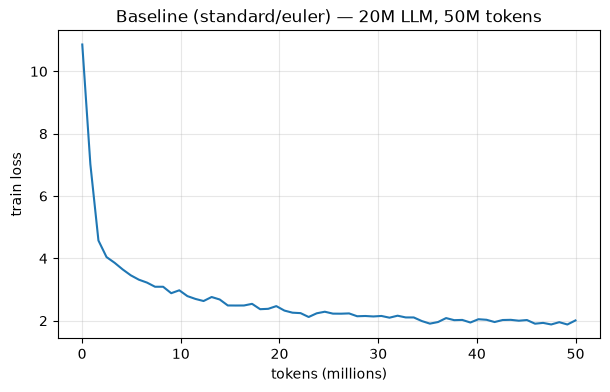

In [6]:
import matplotlib.pyplot as plt
h = res['loss_history']
plt.figure(figsize=(7,4))
plt.plot([x['tokens']/1e6 for x in h], [x['train_loss'] for x in h])
plt.xlabel('tokens (millions)'); plt.ylabel('train loss')
plt.title('Baseline (standard/euler) — 20M LLM, 50M tokens'); plt.grid(alpha=0.3); plt.show()

➡️ Continue to **02 · Reversibility**, where the same model is trained with the leapfrog reversible stack and we compare memory and loss at the same batch.